<a href="https://colab.research.google.com/github/divyaraut17/Deep-Learning/blob/main/DL_Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libary**

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

**2. Load CIFAR-10 Dataset**

In [ ]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

**3. Visualize Sample Images**

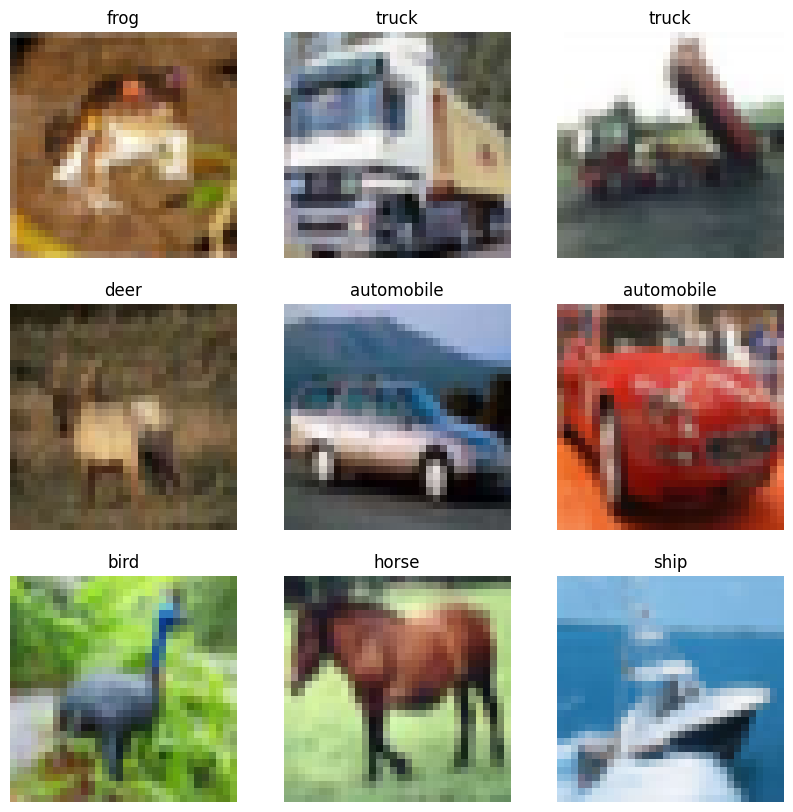

In [ ]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

**Design CNN Architecture**

In [ ]:
model = models.Sequential()
#Convoluational + pooling
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))

#Fully connected
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**5. Compile Model**

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


**6. Train Model**

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.4494 - loss: 1.5128 - val_accuracy: 0.5545 - val_loss: 1.2430
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.5874 - loss: 1.1589 - val_accuracy: 0.5915 - val_loss: 1.1721
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - accuracy: 0.6471 - loss: 1.0055 - val_accuracy: 0.6486 - val_loss: 1.0031
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.6806 - loss: 0.9087 - val_accuracy: 0.6653 - val_loss: 0.9754
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.7080 - loss: 0.8282 - val_accuracy: 0.6827 - val_loss: 0.9277
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.7291 - loss: 0.7706 - val_accuracy: 0.6900 - val_loss: 0.9103
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.7487 - loss: 0.7208 - val_accuracy: 0.7013 - val_loss: 0.8753
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.7633 -

**7. Evaluate Model**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7131 - loss: 0.8635
Test Accuracy: 0.713100016117096


**8. Plot Accuracy Graph**

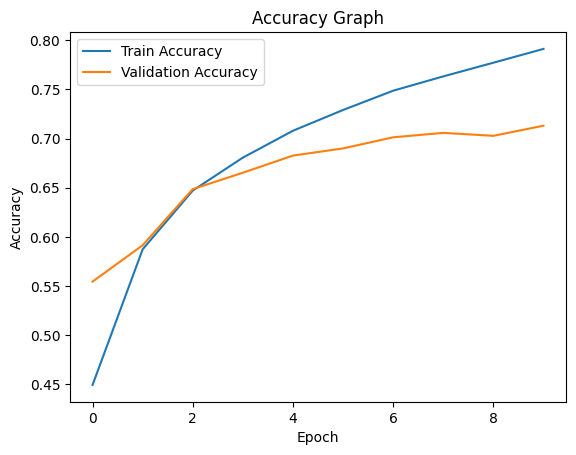

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.show()

**9. Visualize Feature Maps**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


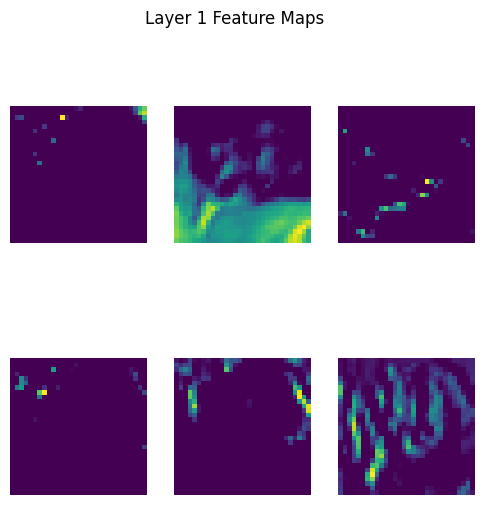

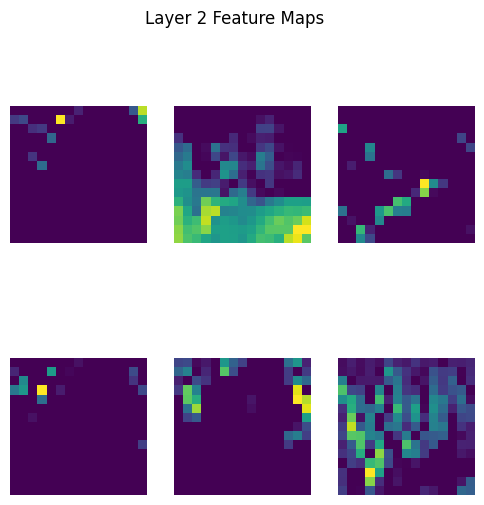

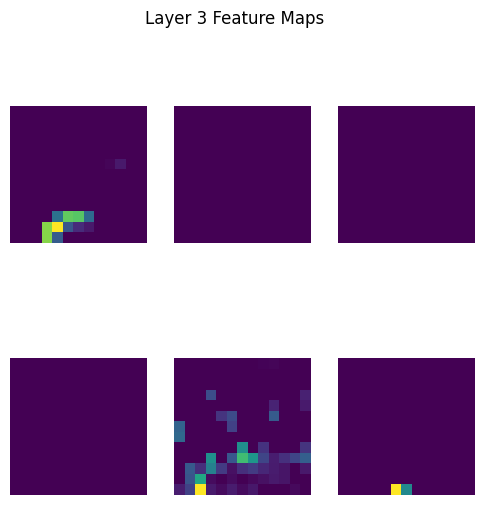

In [ ]:
# Create a model to extract feature maps
layer_outputs = [layer.output for layer in model.layers[:3]]  # first few layers
# Fix: Use the input tensor of the first layer as the input for the activation model.
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

# Take one image
img = x_test[0].reshape(1,32,32,3)

activations = activation_model.predict(img)

# Plot feature maps
for i, activation in enumerate(activations):
    plt.figure(figsize=(6,6))
    for j in range(min(6, activation.shape[-1])):
        plt.subplot(2,3,j+1)
        plt.imshow(activation[0, :, :, j], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f'Layer {i+1} Feature Maps')
    plt.show()